## Grouped CANS Cox Model

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../..').resolve()))

from cox_utils import (
    load_data, cox_incident_table, build_cox_df, fit_cox_model,
    plot_cox_coefs, plot_prior_incident_risk_curve, drill_down,
    plot_partial_effects, plot_90day_probability,
    check_cox_assumptions, plot_profile_risk,
    DEMO_COLS
)

INCIDENT_CAT = 'AWOL_Child_Absense'
INCIDENT_DISPLAY = 'AWOL_Child_Absense'


## Build Incident-Related Cox Table

In [3]:
dfs, top_n_cols, base_cols, incident_cols_dict, group_cols = load_data()
incident_related_cox_table = cox_incident_table(INCIDENT_CAT, dfs, base_cols, incident_cols_dict)
incident_related_cox_table.head()


Found 3 data files. Loading...
Duplicates Removed: 2836
Excluded 591 rows: invalid QuestionKey, missing ChoiceValue, or non-max ChoiceValue within group
1. Initial top_n count: 45
2. Count after removing Index columns: 43
3. Degenerate rows excluded: 48
5. All features have variance.


,OptionsNumber,DateCompleted,Substance Use,Sleep,Decision Making/Judgment,Family Function,Anxiety,Adjustment To Trauma,Social Functioning,Living Situation,...,Next_Assessment,start,stop,start_days,days_since_last_assessment,AWOL_Child_Absense_event_date,AWOL_Child_Absense_event,AWOL_Child_Absense_stop_days,AWOL_Child_Absense_days_since_last_incident,AWOL_Child_Absense_prior_incident_count
0,20034,2022-12-08,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,...,2023-03-08,2022-12-08,2023-03-08,0.0,0.0,NaT,0,90.0,0.0,0
1,20034,2023-03-08,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,...,2023-06-07,2023-03-08,2023-06-07,90.0,90.0,NaT,0,181.0,0.0,0
2,20034,2023-06-07,1.0,0.0,2.0,3.0,1.0,1.0,1.0,2.0,...,2023-07-19,2023-06-07,2023-07-19,181.0,91.0,NaT,0,223.0,0.0,0
3,20034,2023-07-19,1.0,0.0,2.0,3.0,1.0,1.0,1.0,2.0,...,2024-01-15,2023-07-19,2024-01-15,223.0,42.0,NaT,0,403.0,0.0,0
4,20035,2022-12-21,0.0,0.0,3.0,1.0,0.0,2.0,2.0,1.0,...,2023-03-21,2022-12-21,2023-03-21,0.0,0.0,NaT,0,90.0,0.0,0


## Fit Grouped Cox Model

In [4]:
cox_df = build_cox_df(incident_related_cox_table, INCIDENT_CAT, group_cols)
cph = fit_cox_model(cox_df, INCIDENT_CAT)
cph.summary

Shape: (3231, 20)
Events: 97


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
Caregiver_Support_Needs,-0.039861,0.960923,0.030890,-0.100404,0.020683,0.904472,1.020898,0.0,-1.290406,0.196910,2.344393
Internalizing_/_Self-Harm,-0.018002,0.982159,0.032880,-0.082446,0.046441,0.920862,1.047537,0.0,-0.547511,0.584028,0.775891
Developmental_&_Sexual_Concerns,0.042183,1.043085,0.072599,-0.100109,0.184474,0.904739,1.202586,0.0,0.581034,0.561218,0.833367
Externalizing_Behavior,-0.035492,0.965130,0.036210,-0.106463,0.035479,0.899008,1.036116,0.0,-0.980159,0.327008,1.612604
Family_&_Social_Functioning,0.049453,1.050696,0.047747,-0.044129,0.143035,0.956830,1.153771,0.0,1.035731,0.300327,1.735392
Community_&_Strengths,-0.024737,0.975566,0.041283,-0.105651,0.056177,0.899739,1.057785,0.0,-0.599202,0.549038,0.865022
Substance_Use_&_Delinquency,0.326208,1.385703,0.082766,0.163989,0.488426,1.178202,1.629749,0.0,3.941326,0.000081,13.591143
School_Functioning,0.035098,1.035721,0.044966,-0.053033,0.123229,0.948348,1.131143,0.0,0.780548,0.435068,1.200686
Black,-0.009609,0.990437,0.516117,-1.021179,1.001961,0.360170,2.723618,0.0,-0.018617,0.985146,0.021590


## Model Assumption Checks

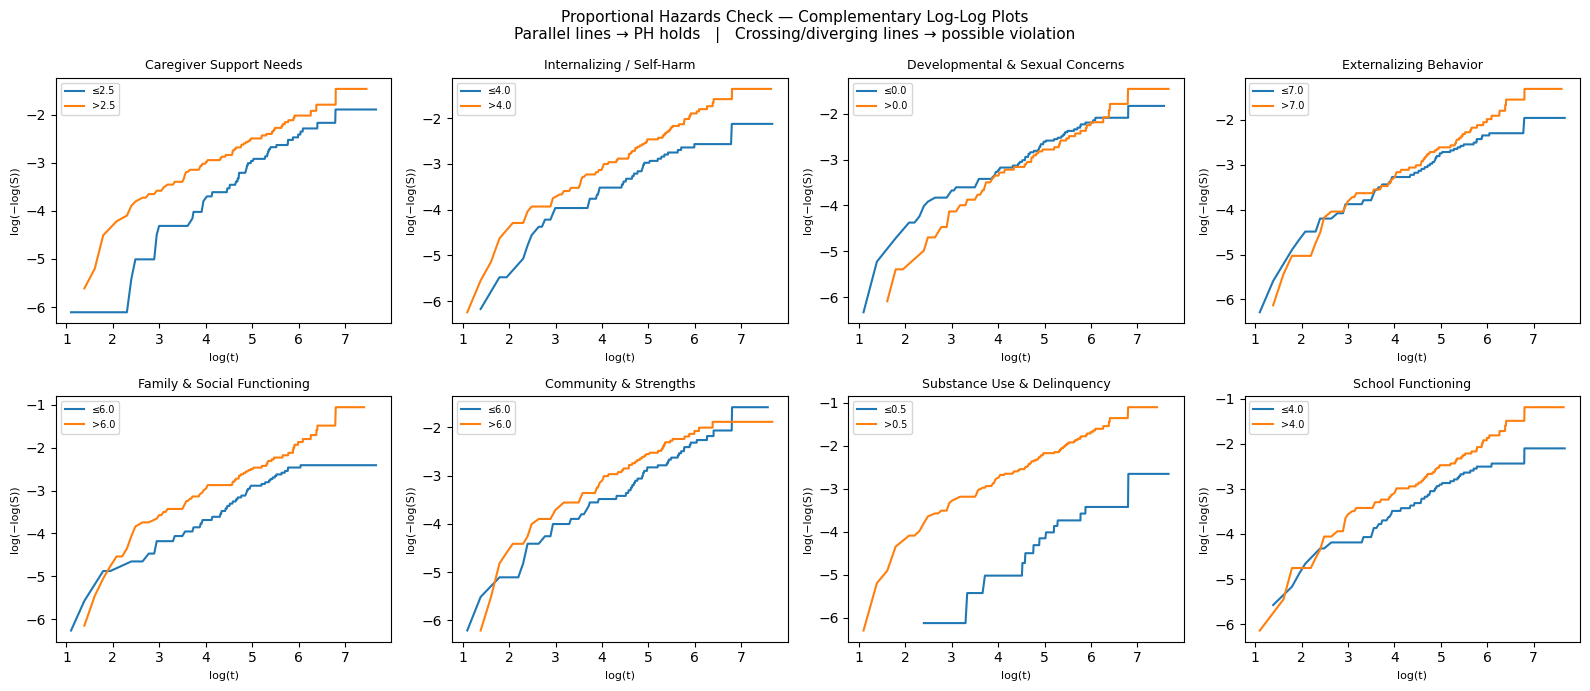

Concordance Index: 0.7950  (0.5 = random, 1.0 = perfect discrimination)


In [5]:
check_cox_assumptions(cph, cox_df, covariates=group_cols)

Each panel shows a **complementary log-log (cll) plot** for one covariate. The y-axis is log(−log(S(t))) and the x-axis is log(t), where S(t) is the Kaplan-Meier survival estimate. Binary covariates are split on their two values; continuous and ordinal covariates are split at the median into a low (≤ median) and high (> median) group. Under the proportional hazards assumption, the two lines for each covariate should run roughly **parallel** across the time axis — a constant vertical offset on the log(−log) scale corresponds to a constant hazard ratio. **Crossing or strongly diverging lines** indicate that the hazard ratio between the two groups changes over time, which is a violation of the PH assumption and suggests that covariate may need to be modeled with a time-varying interaction or stratification. The concordance index printed above the plots summarizes overall model discrimination (0.5 = random, 1.0 = perfect).

## Visualize Group Coefficients

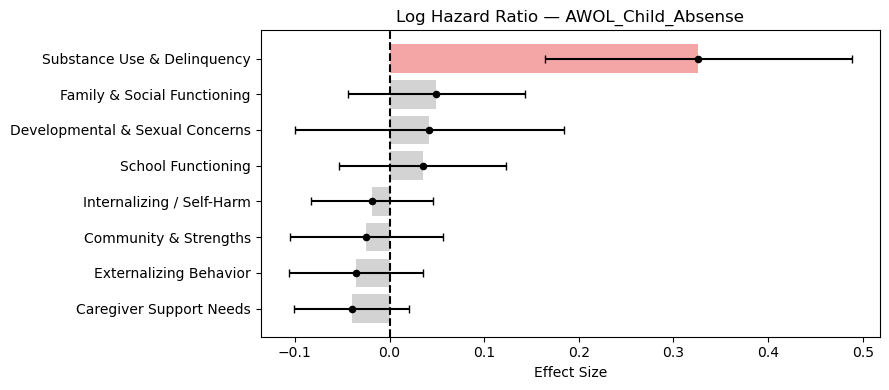

In [6]:
plot_cox_coefs(
    cph,
    exclude_vars=DEMO_COLS + [
        INCIDENT_CAT + '_days_since_last_incident',
        INCIDENT_CAT + '_prior_incident_count'
    ],
    title=f"Log Hazard Ratio — {INCIDENT_DISPLAY}"
)

## Prior Incident Count: Survival Risk Curves

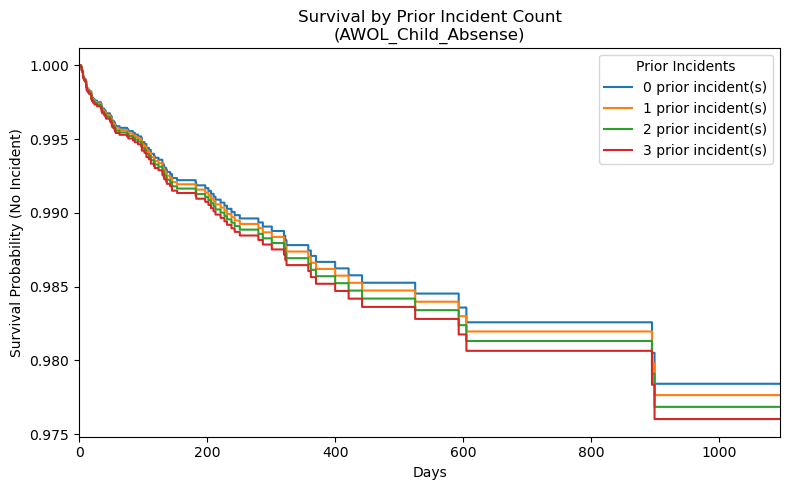

In [7]:
plot_prior_incident_risk_curve(cph, INCIDENT_CAT, INCIDENT_DISPLAY)

## Drill Down: Individual Items in Top Risk Group

Top risk group: Substance_Use_&_Delinquency
Items in group: ['Substance Use', 'Runaway', 'Delinquent Behavior']


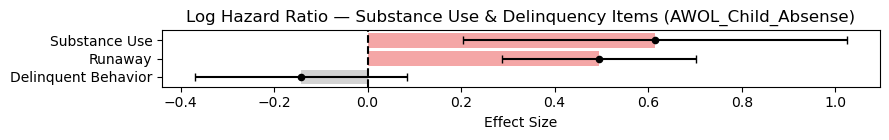


Top 3 most impactful CANS scores:
  Substance Use: coef = 0.6145, p = 3.4097e-03
  Runaway: coef = 0.4957, p = 2.8215e-06
  Delinquent Behavior: coef = -0.1423, p = 2.2017e-01


In [8]:
cph_drill, drill_df, top_items = drill_down(
    cph, group_cols, incident_related_cox_table, INCIDENT_CAT, INCIDENT_DISPLAY
)

## Partial Effects: Survival Curves for Top 3 CANS Scores

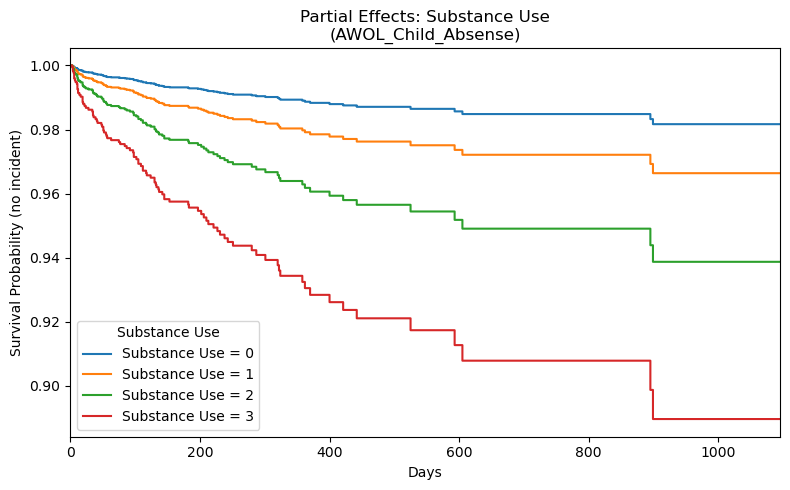

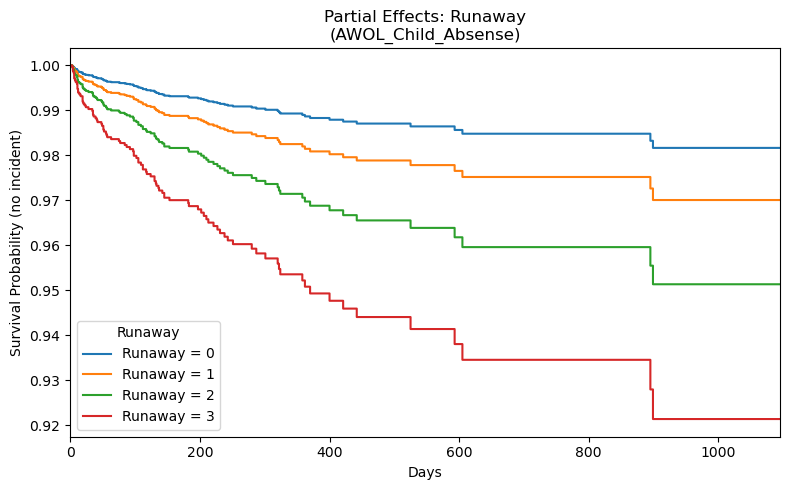

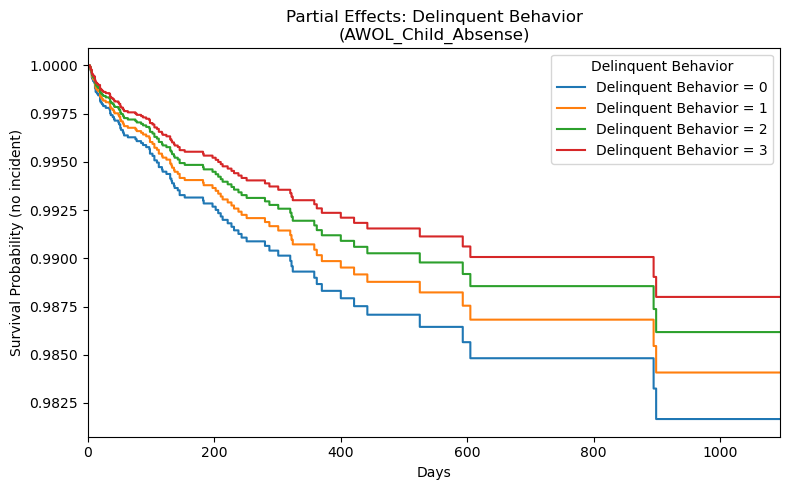

In [9]:
plot_partial_effects(cph_drill, top_items, INCIDENT_DISPLAY)

## 90-Day Incident Probability by Top 3 CANS Score Values

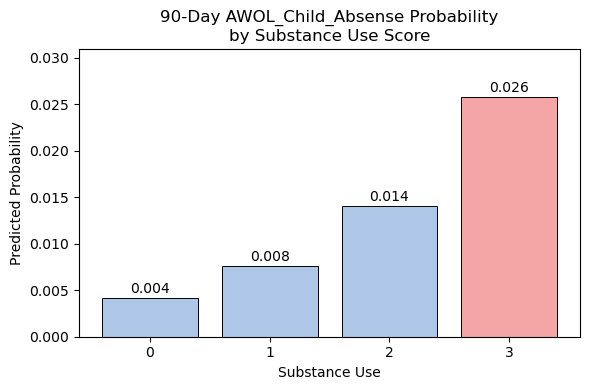

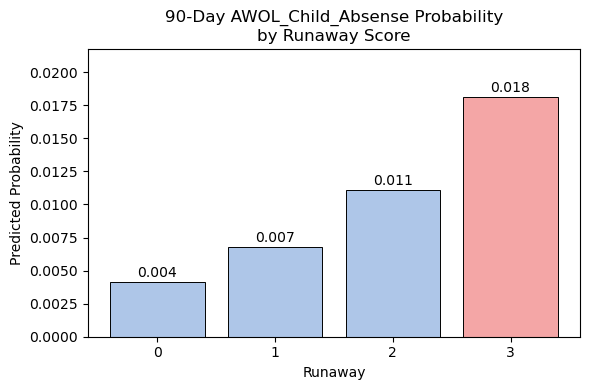

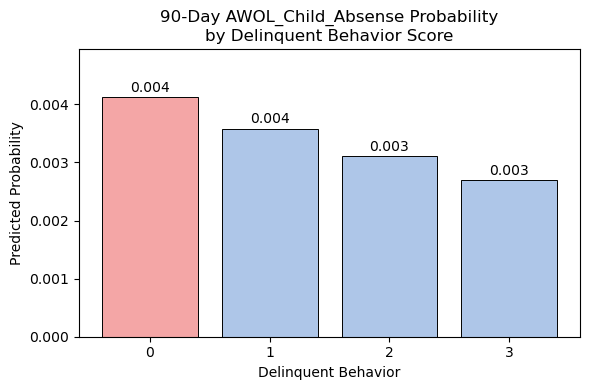

In [10]:
plot_90day_probability(cph_drill, drill_df, INCIDENT_CAT, top_items, INCIDENT_DISPLAY)

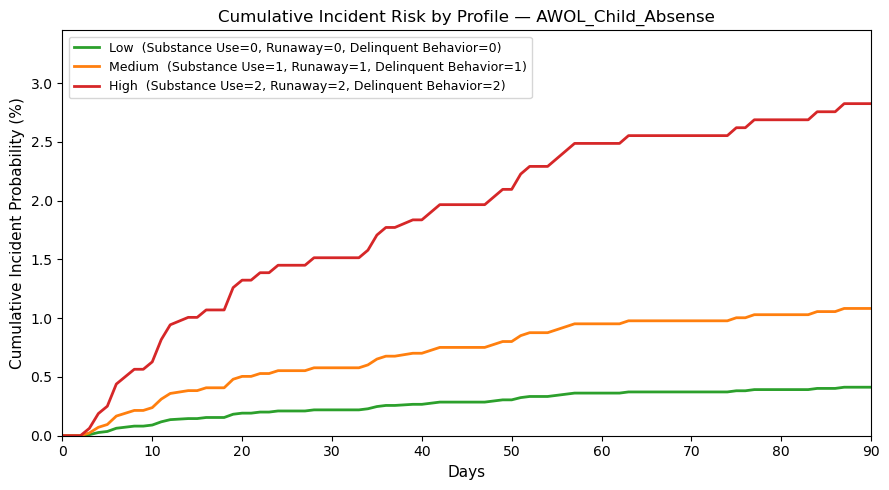

In [11]:
profiles={
        'Low':    {'Substance Use': 0, 'Runaway': 0, 'Delinquent Behavior': 0},
        'Medium': {'Substance Use': 1, 'Runaway': 1, 'Delinquent Behavior': 1},
        'High':   {'Substance Use': 2, 'Runaway': 2, 'Delinquent Behavior': 2},
    }

plot_profile_risk(
    cph_drill, drill_df, INCIDENT_CAT,
   profiles=profiles,
    incident_display=INCIDENT_DISPLAY
);